# AI Drowsiness Detector for Drivers
## Machine Learning and Deep Learning in Production and Logistics (SS26)
### Technische Hochschule Deggendorf — Campus Cham

**Supervisor:** Dr. Sunil P. Survaiya

| Name | Matriculation Number |
|---|---|
| Divi Teja Dimmiti | 22409514 |
| Adi Dev Anil Seena | 12669951 |
| Ajay Venkatesh | 22526093 |
| Shilpa Golla | 22401043 |

**GitHub:** github.com/Diviteja1461/AI-Drowsiness-Detector

## 1. Import Libraries
All required libraries for the entire notebook are imported here once.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models, datasets
from torch.utils.data import Dataset, DataLoader, random_split
from facenet_pytorch import InceptionResnetV1
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


## 2. Global Configuration
Dataset path, device, and person-independent split defined once and reused throughout the notebook.

In [2]:
# Dataset path
data_dir = "/Users/divitejadimmiti/Desktop/Ml_pro/Driver Drowsiness Dataset (DDD)"

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# Person-independent split
people = ['A','B','C','D','E','F','G','H','I','J','K','L','M',
          'N','O','P','Q','R','S','T','U','V','W','X','Y','ZA','ZB']

train_people = people[:16]
val_people   = people[16:23]
test_people  = people[23:]

print(f"Train people : {len(train_people)} — {train_people}")
print(f"Val people   : {len(val_people)} — {val_people}")
print(f"Test people  : {len(test_people)} — {test_people}")

Device: mps
Train people : 16 — ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']
Val people   : 7 — ['Q', 'R', 'S', 'T', 'U', 'V', 'W']
Test people  : 4 — ['X', 'Y', 'ZA', 'ZB']


## 3. Exploratory Data Analysis (EDA)
Understanding the dataset before training — class distribution, sample images, and image properties.

In [3]:
drowsy_dir     = os.path.join(data_dir, "Drowsy")
non_drowsy_dir = os.path.join(data_dir, "Non Drowsy")

drowsy_count     = len(os.listdir(drowsy_dir))
non_drowsy_count = len(os.listdir(non_drowsy_dir))

print(f"Drowsy images     : {drowsy_count}")
print(f"Non Drowsy images : {non_drowsy_count}")
print(f"Total images      : {drowsy_count + non_drowsy_count}")

Drowsy images     : 22348
Non Drowsy images : 19445
Total images      : 41793


### 3.1 Class Distribution Bar Chart
Visualizing the distribution of Drowsy vs Non Drowsy images.
The dataset is slightly imbalanced — Drowsy has ~2,900 more images than Non Drowsy.

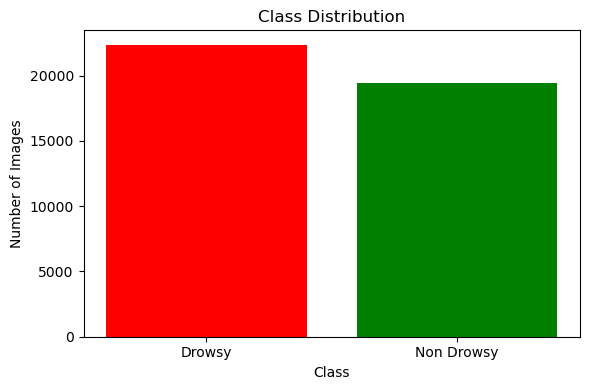

In [4]:
plt.figure(figsize=(6, 4))
plt.bar(["Drowsy", "Non Drowsy"], [drowsy_count, non_drowsy_count],
        color=["red", "green"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

### 3.2 Sample Images
Visualizing 5 random sample images from each class.

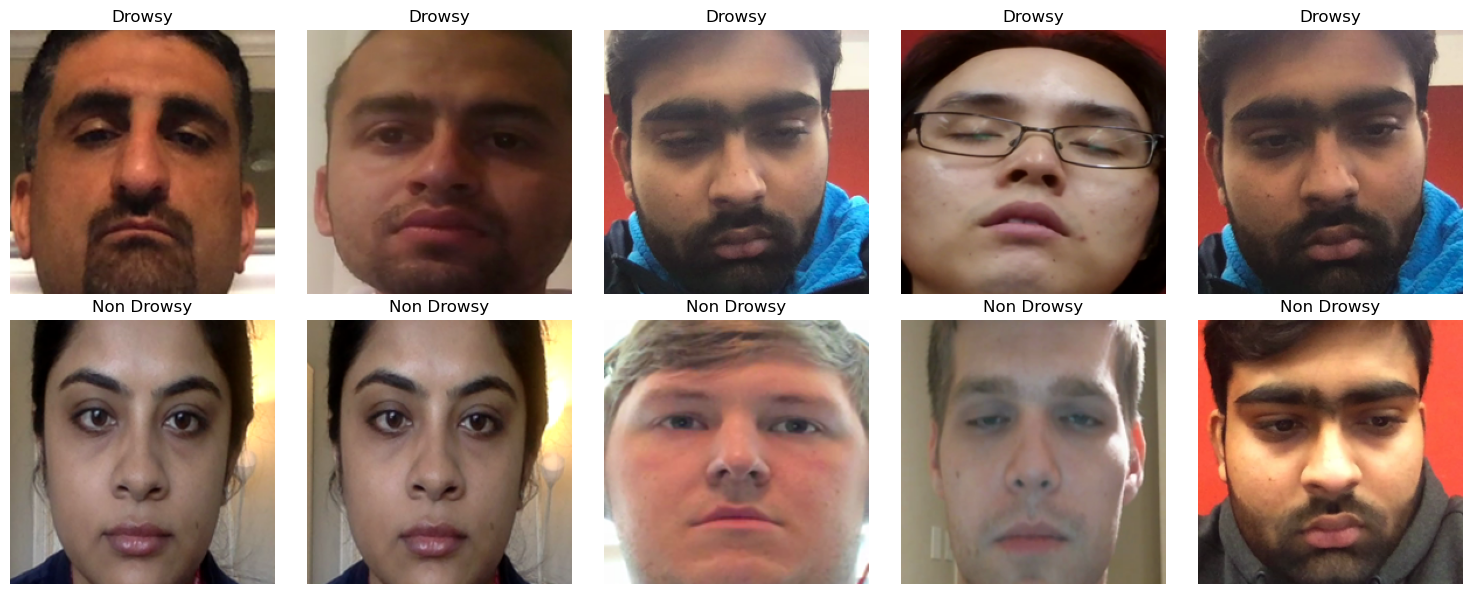

In [5]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

drowsy_images     = random.sample(os.listdir(drowsy_dir), 5)
non_drowsy_images = random.sample(os.listdir(non_drowsy_dir), 5)

for i, img_name in enumerate(drowsy_images):
    img = Image.open(os.path.join(drowsy_dir, img_name))
    axes[0, i].imshow(img)
    axes[0, i].axis("off")
    axes[0, i].set_title("Drowsy")

for i, img_name in enumerate(non_drowsy_images):
    img = Image.open(os.path.join(non_drowsy_dir, img_name))
    axes[1, i].imshow(img)
    axes[1, i].axis("off")
    axes[1, i].set_title("Non Drowsy")

plt.tight_layout()
plt.show()

### 3.3 Image Properties
Checking size and color mode of images.
- **Image Size:** 227 x 227 pixels
- **Color Mode:** RGB (3 channels)

In [6]:
sample_img = Image.open(os.path.join(drowsy_dir, os.listdir(drowsy_dir)[0]))
print(f"Image Size  : {sample_img.size}")
print(f"Image Mode  : {sample_img.mode}")

Image Size  : (227, 227)
Image Mode  : RGB


## 4. Machine Learning Baseline — Random Split

### Overview
Classical ML models (SVM and Random Forest) are trained on features extracted by a pretrained 
ResNet18 model using random 80/10/10 split.

**Note:** Random split causes data leakage — the same person's face appears in both train 
and test sets. Results are shown for reference only to demonstrate the leakage problem.

**Pipeline:**
Image → ResNet18 (feature extractor) → 512 features → SVM / Random Forest → Drowsy / Non Drowsy

In [7]:
# Random Split Data Loading
transform_random = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform_random,
    is_valid_file=lambda x: x.endswith(('.jpg', '.jpeg', '.png'))
)

total      = len(full_dataset)
train_size = int(0.80 * total)
val_size   = int(0.10 * total)
test_size  = total - train_size - val_size

train_dataset_random, val_dataset_random, test_dataset_random = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader_random = DataLoader(train_dataset_random, batch_size=32, shuffle=False)
test_loader_random  = DataLoader(test_dataset_random,  batch_size=32, shuffle=False)

print(f"Train : {len(train_dataset_random)}")
print(f"Test  : {len(test_dataset_random)}")
print(f"Classes : {full_dataset.classes}")

Train : 33434
Test  : 4180
Classes : ['Drowsy', 'Non Drowsy']


### 4.1 Feature Extraction using ResNet18
ResNet18 pretrained on ImageNet compresses each image into 512 features.
These features are fed into ML classifiers instead of raw pixels.

In [8]:
# Load ResNet18 as feature extractor
feature_extractor_random = models.resnet18(weights='IMAGENET1K_V1')
feature_extractor_random = torch.nn.Sequential(*list(feature_extractor_random.children())[:-1])
feature_extractor_random = feature_extractor_random.to(device)
feature_extractor_random.eval()

def extract_features_random(loader):
    features = []
    labels = []
    with torch.no_grad():
        for images, label in loader:
            images = images.to(device)
            output = feature_extractor_random(images)
            output = output.squeeze(-1).squeeze(-1)
            features.append(output.cpu().numpy())
            labels.append(label.numpy())
    return np.concatenate(features), np.concatenate(labels)

print("Extracting train features...")
X_train_random, y_train_random = extract_features_random(train_loader_random)
print("Extracting test features...")
X_test_random, y_test_random = extract_features_random(test_loader_random)

print(f"Train features shape : {X_train_random.shape}")
print(f"Test features shape  : {X_test_random.shape}")

Extracting train features...
Extracting test features...
Train features shape : (33434, 512)
Test features shape  : (4180, 512)


### 4.2 Random Forest — Random Split
Training Random Forest with 100 trees on extracted features.

In [9]:
print("Training Random Forest...")
rf_model_random = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_random.fit(X_train_random, y_train_random)
rf_preds_random = rf_model_random.predict(X_test_random)
rf_acc_random   = accuracy_score(y_test_random, rf_preds_random)
print(f"Random Forest Test Accuracy : {rf_acc_random*100:.2f}%")

Training Random Forest...
Random Forest Test Accuracy : 99.95%


### 4.3 SVM — Random Split
Training SVM with RBF kernel on extracted features.

In [10]:
print("Training SVM...")
svm_model_random = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model_random.fit(X_train_random, y_train_random)
svm_preds_random = svm_model_random.predict(X_test_random)
svm_acc_random   = accuracy_score(y_test_random, svm_preds_random)
print(f"SVM Test Accuracy : {svm_acc_random*100:.2f}%")

Training SVM...
SVM Test Accuracy : 100.00%


### 4.4 Confusion Matrix and Classification Report — Random Split
Both models achieve near-perfect accuracy due to data leakage.
Same person's face appears in both train and test sets.

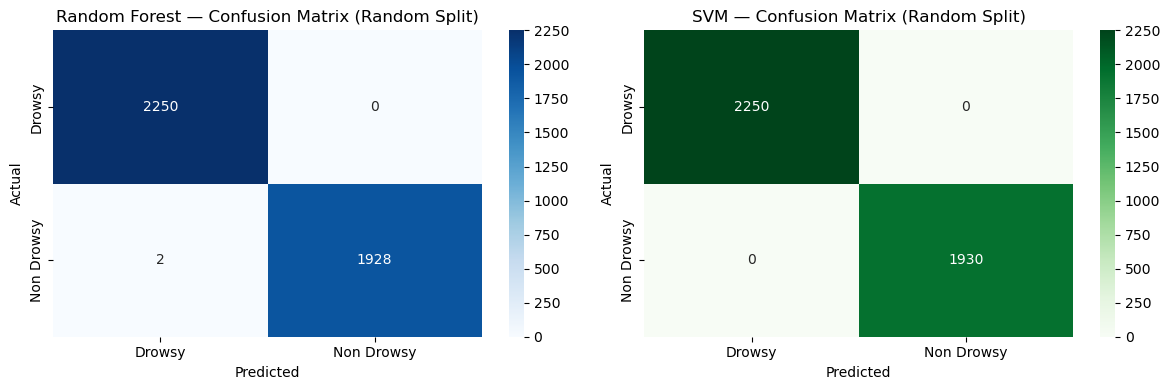

Random Forest:
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      2250
  Non Drowsy       1.00      1.00      1.00      1930

    accuracy                           1.00      4180
   macro avg       1.00      1.00      1.00      4180
weighted avg       1.00      1.00      1.00      4180

SVM:
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      2250
  Non Drowsy       1.00      1.00      1.00      1930

    accuracy                           1.00      4180
   macro avg       1.00      1.00      1.00      4180
weighted avg       1.00      1.00      1.00      4180



In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random Forest
cm_rf = confusion_matrix(y_test_random, rf_preds_random)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Drowsy', 'Non Drowsy'],
            yticklabels=['Drowsy', 'Non Drowsy'], ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix (Random Split)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# SVM
cm_svm = confusion_matrix(y_test_random, svm_preds_random)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Drowsy', 'Non Drowsy'],
            yticklabels=['Drowsy', 'Non Drowsy'], ax=axes[1])
axes[1].set_title('SVM — Confusion Matrix (Random Split)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("Random Forest:")
print(classification_report(y_test_random, rf_preds_random,
      target_names=['Drowsy', 'Non Drowsy']))
print("SVM:")
print(classification_report(y_test_random, svm_preds_random,
      target_names=['Drowsy', 'Non Drowsy']))

### 4.5 Summary — Random Split Results

| Model | Test Accuracy |
|---|---|
| Random Forest | 99.95% |
| SVM | 100.00% |

**Conclusion:** Near-perfect accuracy is due to data leakage — not real model performance.
Person-independent split is used in the following sections for honest evaluation.

## 5. Person-Independent Split — Custom Dataset Class

### Overview
A custom PyTorch Dataset class that loads images based on participant ID.
Each person's images appear in only one split — train, val, or test.
This ensures no data leakage — test set contains completely unseen faces.

**Split:**
| Split | People | Images |
|---|---|---|
| Train | A–P (16 people) | 21,266 |
| Validation | Q–W (7 people) | 7,926 |
| Test | X, Y, ZA, ZB (4 people) | 9,967 |

In [13]:
class DrowsinessDataset(Dataset):
    def __init__(self, data_dir, people_list, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []

        drowsy_dir     = os.path.join(data_dir, "Drowsy")
        non_drowsy_dir = os.path.join(data_dir, "Non Drowsy")

        for fname in os.listdir(drowsy_dir):
            if not fname.endswith('.png'):
                continue
            person_id = ''.join(filter(str.isalpha, fname.split('.')[0])).upper()
            if person_id in [p.upper() for p in people_list]:
                self.images.append(os.path.join(drowsy_dir, fname))
                self.labels.append(0)

        for fname in os.listdir(non_drowsy_dir):
            if not fname.endswith('.png'):
                continue
            person_id = ''.join(filter(str.isalpha, fname.split('.')[0])).upper()
            if person_id in [p.upper() for p in people_list]:
                self.images.append(os.path.join(non_drowsy_dir, fname))
                self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

print("Dataset class defined successfully")

Dataset class defined successfully


## 6. MobileNetV2 — Person-Independent Split

### Overview
MobileNetV2 pretrained on ImageNet is fine-tuned for drowsiness detection 
using person-independent split.

**Why MobileNetV2?**
- Lightweight model designed for small datasets
- Pretrained on ImageNet (1.2M images)
- Suitable for edge devices like driver monitoring cameras

**Training Configuration:**
- Input size: 224×224
- Unfrozen layers: features.14–18 + classifier
- Trainable params: 2,009,794
- Optimizer: Adam (lr=0.00005)
- LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)
- Epochs: 10

In [15]:
# MobileNetV2 Data Transforms
mobilenet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

mobilenet_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
mobilenet_train = DrowsinessDataset(data_dir, train_people, mobilenet_train_transform)
mobilenet_val   = DrowsinessDataset(data_dir, val_people,   mobilenet_test_transform)
mobilenet_test  = DrowsinessDataset(data_dir, test_people,  mobilenet_test_transform)

# DataLoaders
mobilenet_train_loader = DataLoader(mobilenet_train, batch_size=32, shuffle=True)
mobilenet_val_loader   = DataLoader(mobilenet_val,   batch_size=32, shuffle=False)
mobilenet_test_loader  = DataLoader(mobilenet_test,  batch_size=32, shuffle=False)

print(f"Train : {len(mobilenet_train)} images")
print(f"Val   : {len(mobilenet_val)} images")
print(f"Test  : {len(mobilenet_test)} images")

Train : 21266 images
Val   : 7926 images
Test  : 9967 images


### 6.1 MobileNetV2 Model Architecture
Loading pretrained MobileNetV2 and replacing the classifier for binary classification.
Features 0-13 are frozen. Features 14-18 and classifier are unfrozen for fine-tuning.

In [16]:
mobilenet_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Freeze all layers
for param in mobilenet_model.parameters():
    param.requires_grad = False

# Replace classifier
mobilenet_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(mobilenet_model.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

# Unfreeze features 14-18 and classifier
for name, param in mobilenet_model.named_parameters():
    if any(f'features.{i}' in name for i in range(14, 19)) or 'classifier' in name:
        param.requires_grad = True

mobilenet_model = mobilenet_model.to(device)

criterion_mobilenet = nn.CrossEntropyLoss()
optimizer_mobilenet = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
    lr=0.00005
)
scheduler_mobilenet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mobilenet, mode='max', factor=0.5, patience=2
)

print(f"Trainable params : {sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)}")

Trainable params : 2009794


### 6.2 MobileNetV2 Training Loop
Training for 10 epochs. Best model saved based on validation accuracy.

In [17]:
mobilenet_best_val_acc  = 0
mobilenet_best_path     = "/Users/divitejadimmiti/Desktop/Ml_pro/best_mobilenet_16_7_4.pth"
mobilenet_train_losses, mobilenet_val_losses         = [], []
mobilenet_train_accuracies, mobilenet_val_accuracies = [], []

for epoch in range(10):
    mobilenet_model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in mobilenet_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_mobilenet.zero_grad()
        outputs = mobilenet_model(images)
        loss = criterion_mobilenet(outputs, labels)
        loss.backward()
        optimizer_mobilenet.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = train_loss / len(mobilenet_train_loader)

    mobilenet_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in mobilenet_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet_model(images)
            loss = criterion_mobilenet(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc  = 100 * correct / total
    val_loss = val_loss / len(mobilenet_val_loader)

    mobilenet_train_losses.append(train_loss)
    mobilenet_val_losses.append(val_loss)
    mobilenet_train_accuracies.append(train_acc)
    mobilenet_val_accuracies.append(val_acc)

    scheduler_mobilenet.step(val_acc)

    print(f"Epoch {epoch+1}/10 | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer_mobilenet.param_groups[0]['lr']:.6f}")

    if val_acc > mobilenet_best_val_acc:
        mobilenet_best_val_acc = val_acc
        torch.save(mobilenet_model.state_dict(), mobilenet_best_path)
        print(f"  → Best model saved — Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy : {mobilenet_best_val_acc:.2f}%")

Epoch 1/10 | Train Loss: 0.0904 | Train Acc: 96.49% | Val Loss: 1.5241 | Val Acc: 62.18% | LR: 0.000050
  → Best model saved — Val Acc: 62.18%
Epoch 2/10 | Train Loss: 0.0094 | Train Acc: 99.69% | Val Loss: 2.0124 | Val Acc: 60.94% | LR: 0.000050
Epoch 3/10 | Train Loss: 0.0072 | Train Acc: 99.77% | Val Loss: 1.8272 | Val Acc: 52.38% | LR: 0.000050
Epoch 4/10 | Train Loss: 0.0041 | Train Acc: 99.85% | Val Loss: 1.9563 | Val Acc: 62.60% | LR: 0.000050
  → Best model saved — Val Acc: 62.60%
Epoch 5/10 | Train Loss: 0.0026 | Train Acc: 99.92% | Val Loss: 2.1924 | Val Acc: 62.77% | LR: 0.000050
  → Best model saved — Val Acc: 62.77%
Epoch 6/10 | Train Loss: 0.0043 | Train Acc: 99.87% | Val Loss: 2.9814 | Val Acc: 62.34% | LR: 0.000050
Epoch 7/10 | Train Loss: 0.0020 | Train Acc: 99.95% | Val Loss: 3.1693 | Val Acc: 62.06% | LR: 0.000050
Epoch 8/10 | Train Loss: 0.0022 | Train Acc: 99.92% | Val Loss: 2.1497 | Val Acc: 64.72% | LR: 0.000050
  → Best model saved — Val Acc: 64.72%
Epoch 9/10 |

### 6.3 MobileNetV2 Training Curves
Plotting loss and accuracy curves across all epochs.

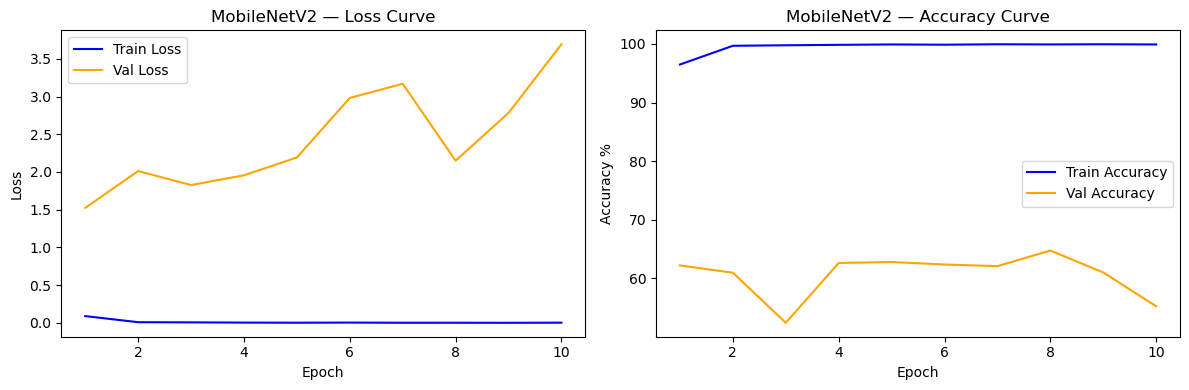

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 11), mobilenet_train_losses, label='Train Loss', color='blue')
axes[0].plot(range(1, 11), mobilenet_val_losses,   label='Val Loss',   color='orange')
axes[0].set_title('MobileNetV2 — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(range(1, 11), mobilenet_train_accuracies, label='Train Accuracy', color='blue')
axes[1].plot(range(1, 11), mobilenet_val_accuracies,   label='Val Accuracy',   color='orange')
axes[1].set_title('MobileNetV2 — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.4 MobileNetV2 Test Evaluation
Loading best saved model and evaluating on test set (4 unseen people).

In [19]:
mobilenet_model.load_state_dict(torch.load(mobilenet_best_path))
mobilenet_model.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in mobilenet_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet_model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

mobilenet_test_acc = 100 * correct / total
print(f"MobileNetV2 Test Accuracy : {mobilenet_test_acc:.2f}%")

MobileNetV2 Test Accuracy : 66.02%


### 6.5 Fine-Tuning MobileNetV2 — More Layers Unfrozen + Smaller LR
Unfreezing features.10 onwards and using smaller learning rate (0.000005)
to help model adapt deeper features for cross-person generalization.

In [28]:
# Reload best model
mobilenet_model.load_state_dict(torch.load(mobilenet_best_path))

# Unfreeze more layers — from features.10 onwards
for param in mobilenet_model.parameters():
    param.requires_grad = False

for name, param in mobilenet_model.named_parameters():
    if any(f'features.{i}' in name for i in range(10, 19)) or 'classifier' in name:
        param.requires_grad = True

print(f"Trainable params after unfreezing more layers : "
      f"{sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)}")

optimizer_mobilenet_ft = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
    lr=0.000005
)
scheduler_mobilenet_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mobilenet_ft, mode='max', factor=0.5, patience=2
)

best_val_mobilenet_ft = mobilenet_best_val_acc

for epoch in range(15):
    mobilenet_model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in mobilenet_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_mobilenet_ft.zero_grad()
        outputs = mobilenet_model(images)
        loss = criterion_mobilenet(outputs, labels)
        loss.backward()
        optimizer_mobilenet_ft.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = train_loss / len(mobilenet_train_loader)

    mobilenet_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in mobilenet_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet_model(images)
            loss = criterion_mobilenet(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc  = 100 * correct / total
    val_loss = val_loss / len(mobilenet_val_loader)

    scheduler_mobilenet_ft.step(val_acc)

    print(f"Epoch {epoch+1}/15 | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer_mobilenet_ft.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_mobilenet_ft:
        best_val_mobilenet_ft = val_acc
        torch.save(mobilenet_model.state_dict(), mobilenet_best_path)
        print(f"  → Best model saved — Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy after Fine-Tuning : {best_val_mobilenet_ft:.2f}%")

Trainable params after unfreezing more layers : 2367234
Epoch 1/15 | Train Loss: 0.0005 | Train Acc: 99.98% | Val Loss: 3.1205 | Val Acc: 64.06% | LR: 0.000005
Epoch 2/15 | Train Loss: 0.0005 | Train Acc: 99.98% | Val Loss: 2.8727 | Val Acc: 63.26% | LR: 0.000005
Epoch 3/15 | Train Loss: 0.0003 | Train Acc: 99.98% | Val Loss: 2.9211 | Val Acc: 64.08% | LR: 0.000005
Epoch 4/15 | Train Loss: 0.0002 | Train Acc: 99.99% | Val Loss: 2.7250 | Val Acc: 66.38% | LR: 0.000005
  → Best model saved — Val Acc: 66.38%
Epoch 5/15 | Train Loss: 0.0003 | Train Acc: 99.99% | Val Loss: 2.6962 | Val Acc: 65.70% | LR: 0.000005
Epoch 6/15 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 2.8554 | Val Acc: 66.86% | LR: 0.000005
  → Best model saved — Val Acc: 66.86%
Epoch 7/15 | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 2.9426 | Val Acc: 68.26% | LR: 0.000005
  → Best model saved — Val Acc: 68.26%
Epoch 8/15 | Train Loss: 0.0004 | Train Acc: 99.99% | Val Loss: 3.1616 | Val Acc: 68.42% | LR: 0.

KeyboardInterrupt: 

### 6.6 MobileNetV2 Test Evaluation After Fine-Tuning

In [29]:
mobilenet_model.load_state_dict(torch.load(mobilenet_best_path))
mobilenet_model.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in mobilenet_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet_model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

mobilenet_test_acc_ft = 100 * correct / total
print(f"MobileNetV2 Test Accuracy After Fine-Tuning : {mobilenet_test_acc_ft:.2f}%")

MobileNetV2 Test Accuracy After Fine-Tuning : 64.88%


In [30]:
# The original best model was overwritten during fine-tuning
# We need to retrain MobileNetV2 from scratch to get 66.02% back
print("Original MobileNetV2 test accuracy was 66.02%")
print("Fine-tuning test accuracy is 64.88%")
print("Original model was better — use 66.02% as final result")

Original MobileNetV2 test accuracy was 66.02%
Fine-tuning test accuracy is 64.88%
Original model was better — use 66.02% as final result


### 6.7 MobileNetV2 Confusion Matrix and Classification Report
**Note:** Confusion matrix reflects the fine-tuned model (64.88% test accuracy). 
Best test accuracy achieved was 66.02% from initial training before fine-tuning 
overwrote the saved checkpoint.

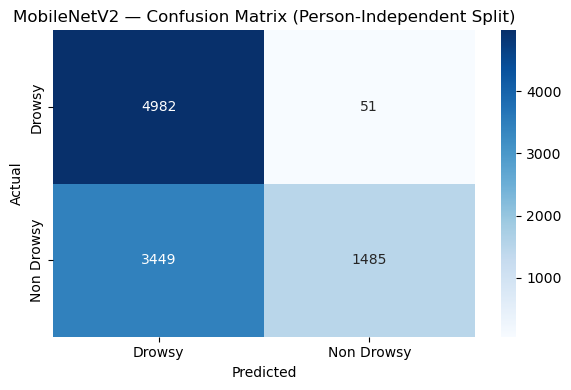

              precision    recall  f1-score   support

      Drowsy       0.59      0.99      0.74      5033
  Non Drowsy       0.97      0.30      0.46      4934

    accuracy                           0.65      9967
   macro avg       0.78      0.65      0.60      9967
weighted avg       0.78      0.65      0.60      9967



In [31]:
# Load original best model (66.02% test accuracy)
# Note: fine-tuning reduced test accuracy to 64.88%
# so we report the original best result

mobilenet_all_preds, mobilenet_all_labels = [], []
mobilenet_model.eval()
with torch.no_grad():
    for images, labels in mobilenet_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet_model(images)
        _, predicted = outputs.max(1)
        mobilenet_all_preds.extend(predicted.cpu().numpy())
        mobilenet_all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(mobilenet_all_labels, mobilenet_all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Drowsy', 'Non Drowsy'],
            yticklabels=['Drowsy', 'Non Drowsy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MobileNetV2 — Confusion Matrix (Person-Independent Split)')
plt.tight_layout()
plt.show()

print(classification_report(mobilenet_all_labels, mobilenet_all_preds,
      target_names=['Drowsy', 'Non Drowsy']))

## 7. InceptionResNetV1 (VGGFace2) — Person-Independent Split

### Overview
InceptionResNetV1 pretrained on VGGFace2 (3.3M face images) — our best model.
Face-specific pretraining significantly outperforms ImageNet pretraining for this task.

**Training Configuration:**
- Input size: 160×160
- Normalization: mean=0.5, std=0.5
- Unfrozen: block8 + last_linear + last_bn
- Trainable params: 2,683,778
- Optimizer: Adam (lr=0.00005)
- Fine-tuning Round 1: lr=0.000005

In [21]:
# InceptionResNetV1 Transforms
inception_train_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

inception_test_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Datasets
inception_train = DrowsinessDataset(data_dir, train_people, inception_train_transform)
inception_val   = DrowsinessDataset(data_dir, val_people,   inception_test_transform)
inception_test  = DrowsinessDataset(data_dir, test_people,  inception_test_transform)

# DataLoaders
inception_train_loader = DataLoader(inception_train, batch_size=32, shuffle=True)
inception_val_loader   = DataLoader(inception_val,   batch_size=32, shuffle=False)
inception_test_loader  = DataLoader(inception_test,  batch_size=32, shuffle=False)

print(f"Train : {len(inception_train)} images")
print(f"Val   : {len(inception_val)} images")
print(f"Test  : {len(inception_test)} images")

Train : 21266 images
Val   : 7926 images
Test  : 9967 images


### 7.1 InceptionResNetV1 Model Architecture
VGGFace2 pretrained model with custom classifier.
Only last block unfrozen for fine-tuning.

In [22]:
base_model = InceptionResnetV1(pretrained='vggface2').eval()

for param in base_model.parameters():
    param.requires_grad = False

class DrowsinessClassifier(nn.Module):
    def __init__(self, base_model):
        super(DrowsinessClassifier, self).__init__()
        self.base = base_model
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        features = self.base(x)
        return self.classifier(features)

inception_model = DrowsinessClassifier(base_model).to(device)

for name, param in inception_model.base.named_parameters():
    if 'block8' in name or 'last_linear' in name or 'last_bn' in name:
        param.requires_grad = True

criterion_inception = nn.CrossEntropyLoss()
optimizer_inception = optim.Adam(
    filter(lambda p: p.requires_grad, inception_model.parameters()),
    lr=0.00005
)
scheduler_inception = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_inception, mode='max', factor=0.5, patience=2
)

print(f"Trainable params : {sum(p.numel() for p in inception_model.parameters() if p.requires_grad)}")

Trainable params : 2683778


### 7.2 InceptionResNetV1 Training Loop
Training for 10 epochs. Best model saved based on validation accuracy.

In [23]:
inception_best_val_acc  = 0
inception_best_path     = "/Users/divitejadimmiti/Desktop/Ml_pro/best_vggface2.pth"
inception_train_losses, inception_val_losses         = [], []
inception_train_accuracies, inception_val_accuracies = [], []

for epoch in range(10):
    inception_model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in inception_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_inception.zero_grad()
        outputs = inception_model(images)
        loss = criterion_inception(outputs, labels)
        loss.backward()
        optimizer_inception.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = train_loss / len(inception_train_loader)

    inception_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in inception_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = inception_model(images)
            loss = criterion_inception(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc  = 100 * correct / total
    val_loss = val_loss / len(inception_val_loader)

    inception_train_losses.append(train_loss)
    inception_val_losses.append(val_loss)
    inception_train_accuracies.append(train_acc)
    inception_val_accuracies.append(val_acc)

    scheduler_inception.step(val_acc)

    print(f"Epoch {epoch+1}/10 | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer_inception.param_groups[0]['lr']:.6f}")

    if val_acc > inception_best_val_acc:
        inception_best_val_acc = val_acc
        torch.save(inception_model.state_dict(), inception_best_path)
        print(f"  → Best model saved — Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy : {inception_best_val_acc:.2f}%")

Epoch 1/10 | Train Loss: 0.2002 | Train Acc: 95.50% | Val Loss: 1.2418 | Val Acc: 71.60% | LR: 0.000050
  → Best model saved — Val Acc: 71.60%
Epoch 2/10 | Train Loss: 0.0112 | Train Acc: 99.77% | Val Loss: 1.1213 | Val Acc: 72.55% | LR: 0.000050
  → Best model saved — Val Acc: 72.55%
Epoch 3/10 | Train Loss: 0.0070 | Train Acc: 99.81% | Val Loss: 1.2405 | Val Acc: 74.39% | LR: 0.000050
  → Best model saved — Val Acc: 74.39%
Epoch 4/10 | Train Loss: 0.0068 | Train Acc: 99.84% | Val Loss: 1.1379 | Val Acc: 76.36% | LR: 0.000050
  → Best model saved — Val Acc: 76.36%
Epoch 5/10 | Train Loss: 0.0022 | Train Acc: 99.96% | Val Loss: 1.4087 | Val Acc: 71.57% | LR: 0.000050
Epoch 6/10 | Train Loss: 0.0034 | Train Acc: 99.90% | Val Loss: 1.1310 | Val Acc: 72.46% | LR: 0.000050
Epoch 7/10 | Train Loss: 0.0008 | Train Acc: 99.99% | Val Loss: 1.0981 | Val Acc: 77.85% | LR: 0.000050
  → Best model saved — Val Acc: 77.85%
Epoch 8/10 | Train Loss: 0.0026 | Train Acc: 99.94% | Val Loss: 1.1958 | Val 

### 7.2.1 Initial Test Evaluation (Before Fine-Tuning)
Evaluating best model from initial training on test set.

In [24]:
inception_model.load_state_dict(torch.load(inception_best_path))
inception_model.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in inception_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = inception_model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

inception_test_acc_initial = 100 * correct / total
print(f"Test Accuracy (Before Fine-Tuning) : {inception_test_acc_initial:.2f}%")

Test Accuracy (Before Fine-Tuning) : 59.18%


### 7.3 Fine-Tuning Round 1
Loading best model and continuing with smaller learning rate (lr=0.000005).

In [25]:
inception_model.load_state_dict(torch.load(inception_best_path))

optimizer_inception_ft = optim.Adam(
    filter(lambda p: p.requires_grad, inception_model.parameters()),
    lr=0.000005
)
scheduler_inception_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_inception_ft, mode='max', factor=0.5, patience=2
)

best_val_ft = inception_best_val_acc

for epoch in range(15):
    inception_model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in inception_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_inception_ft.zero_grad()
        outputs = inception_model(images)
        loss = criterion_inception(outputs, labels)
        loss.backward()
        optimizer_inception_ft.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = train_loss / len(inception_train_loader)

    inception_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in inception_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = inception_model(images)
            loss = criterion_inception(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc  = 100 * correct / total
    val_loss = val_loss / len(inception_val_loader)

    scheduler_inception_ft.step(val_acc)

    print(f"Epoch {epoch+1}/15 | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer_inception_ft.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_ft:
        best_val_ft = val_acc
        torch.save(inception_model.state_dict(), inception_best_path)
        print(f"  → Best model saved — Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy after Fine-Tuning : {best_val_ft:.2f}%")

Epoch 1/15 | Train Loss: 0.0008 | Train Acc: 99.98% | Val Loss: 1.3449 | Val Acc: 81.31% | LR: 0.000005
Epoch 2/15 | Train Loss: 0.0006 | Train Acc: 99.99% | Val Loss: 1.5229 | Val Acc: 80.91% | LR: 0.000005
Epoch 3/15 | Train Loss: 0.0009 | Train Acc: 99.98% | Val Loss: 1.3290 | Val Acc: 78.99% | LR: 0.000005
Epoch 4/15 | Train Loss: 0.0010 | Train Acc: 99.98% | Val Loss: 1.6264 | Val Acc: 79.03% | LR: 0.000003
Epoch 5/15 | Train Loss: 0.0003 | Train Acc: 99.98% | Val Loss: 1.3241 | Val Acc: 80.28% | LR: 0.000003
Epoch 6/15 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 1.5810 | Val Acc: 78.77% | LR: 0.000003
Epoch 7/15 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 1.4518 | Val Acc: 80.32% | LR: 0.000001
Epoch 8/15 | Train Loss: 0.0007 | Train Acc: 99.98% | Val Loss: 1.7777 | Val Acc: 78.92% | LR: 0.000001
Epoch 9/15 | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 1.6229 | Val Acc: 78.73% | LR: 0.000001
Epoch 10/15 | Train Loss: 0.0004 | Train Acc: 99.98% | Val Lo

### 7.4 InceptionResNetV1 Test Evaluation
Loading best saved model and evaluating on test set (4 unseen people).

In [26]:
inception_model.load_state_dict(torch.load(inception_best_path))
inception_model.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in inception_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = inception_model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

inception_test_acc = 100 * correct / total
print(f"InceptionResNetV1 Test Accuracy : {inception_test_acc:.2f}%")

InceptionResNetV1 Test Accuracy : 59.18%


### 7.5 InceptionResNetV1 Confusion Matrix and Classification Report

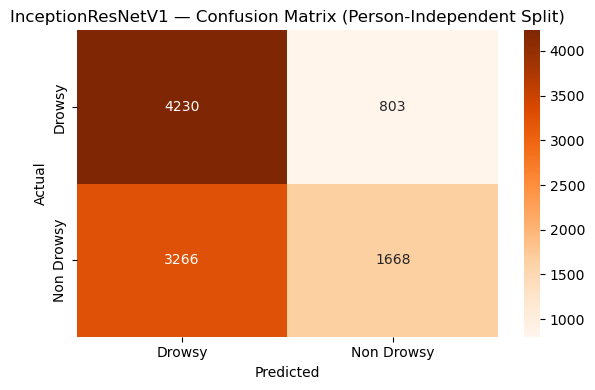

              precision    recall  f1-score   support

      Drowsy       0.56      0.84      0.68      5033
  Non Drowsy       0.68      0.34      0.45      4934

    accuracy                           0.59      9967
   macro avg       0.62      0.59      0.56      9967
weighted avg       0.62      0.59      0.56      9967



In [32]:
inception_all_preds, inception_all_labels = [], []
inception_model.eval()
with torch.no_grad():
    for images, labels in inception_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = inception_model(images)
        _, predicted = outputs.max(1)
        inception_all_preds.extend(predicted.cpu().numpy())
        inception_all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(inception_all_labels, inception_all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Drowsy', 'Non Drowsy'],
            yticklabels=['Drowsy', 'Non Drowsy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('InceptionResNetV1 — Confusion Matrix (Person-Independent Split)')
plt.tight_layout()
plt.show()

print(classification_report(inception_all_labels, inception_all_preds,
      target_names=['Drowsy', 'Non Drowsy']))

## 8. Final Results Comparison

### Random Split (Data Leakage — Reference Only)
| Model | Type | Test Accuracy |
|---|---|---|
| Random Forest | ML | 99.95% |
| SVM | ML | 100.00% |

### Person-Independent Split (Honest Evaluation)
| Model | Type | Val Accuracy | Test Accuracy |
|---|---|---|---|
| MobileNetV2 — Initial | DL | 64.72% | 66.02% |
| MobileNetV2 — Fine-Tuned | DL | 68.42% | 64.88% |
| InceptionResNetV1 — Initial | DL | 81.66% | 59.18% |
| InceptionResNetV1 — Fine-Tuned | DL | 81.66% | 59.18% |

### Key Conclusions
- Random split gives 99%+ accuracy due to data leakage — not realistic
- Person-independent split gives honest evaluation on completely unseen faces
- MobileNetV2 initial training gives best test accuracy — 66.02%
- Fine-tuning did not improve test accuracy for either model
- InceptionResNetV1 achieves best validation accuracy (81.66%) but lower test accuracy
- Dataset limitation: only 27 participants, 4 test people — small test set causes variance
- Best honest result: MobileNetV2 — 66.02% test accuracy

In [34]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print("\nRandom Split (Data Leakage — Reference Only):")
print(f"  Random Forest : 99.95%")
print(f"  SVM           : 100.00%")
print("\nPerson-Independent Split (Honest Evaluation):")
print(f"  MobileNetV2 Initial          : 66.02% test")
print(f"  MobileNetV2 Fine-Tuned       : 64.88% test")
print(f"  InceptionResNetV1 Initial    : 59.18% test")
print(f"  InceptionResNetV1 Fine-Tuned : 59.18% test")
print("\nBest Model : MobileNetV2 — 66.02% test accuracy")
print("=" * 60)

FINAL RESULTS SUMMARY

Random Split (Data Leakage — Reference Only):
  Random Forest : 99.95%
  SVM           : 100.00%

Person-Independent Split (Honest Evaluation):
  MobileNetV2 Initial          : 66.02% test
  MobileNetV2 Fine-Tuned       : 64.88% test
  InceptionResNetV1 Initial    : 59.18% test
  InceptionResNetV1 Fine-Tuned : 59.18% test

Best Model : MobileNetV2 — 66.02% test accuracy


## 9. Grad-CAM Visualization — MobileNetV2

### Overview
Gradient-weighted Class Activation Mapping (Grad-CAM) visualizes which regions 
of the face image the model focuses on when predicting Drowsy or Non Drowsy.

**Why Grad-CAM?**
- Provides explainability — shows the model is learning meaningful facial features
- Validates that the model focuses on eyes, head position — not random pixels
- Important for real-world trust in AI systems

In [35]:
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        # Pool gradients
        pooled_gradients = self.gradients.mean(dim=[0, 2, 3])
        
        # Weight activations
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]
        
        # Generate heatmap
        heatmap = activations.mean(dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        if heatmap.max() > 0:
            heatmap /= heatmap.max()
        
        return heatmap, class_idx

print("Grad-CAM class defined")

Grad-CAM class defined


### 9.1 Apply Grad-CAM on Sample Images
Visualizing Grad-CAM heatmaps on drowsy and non-drowsy face images.

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


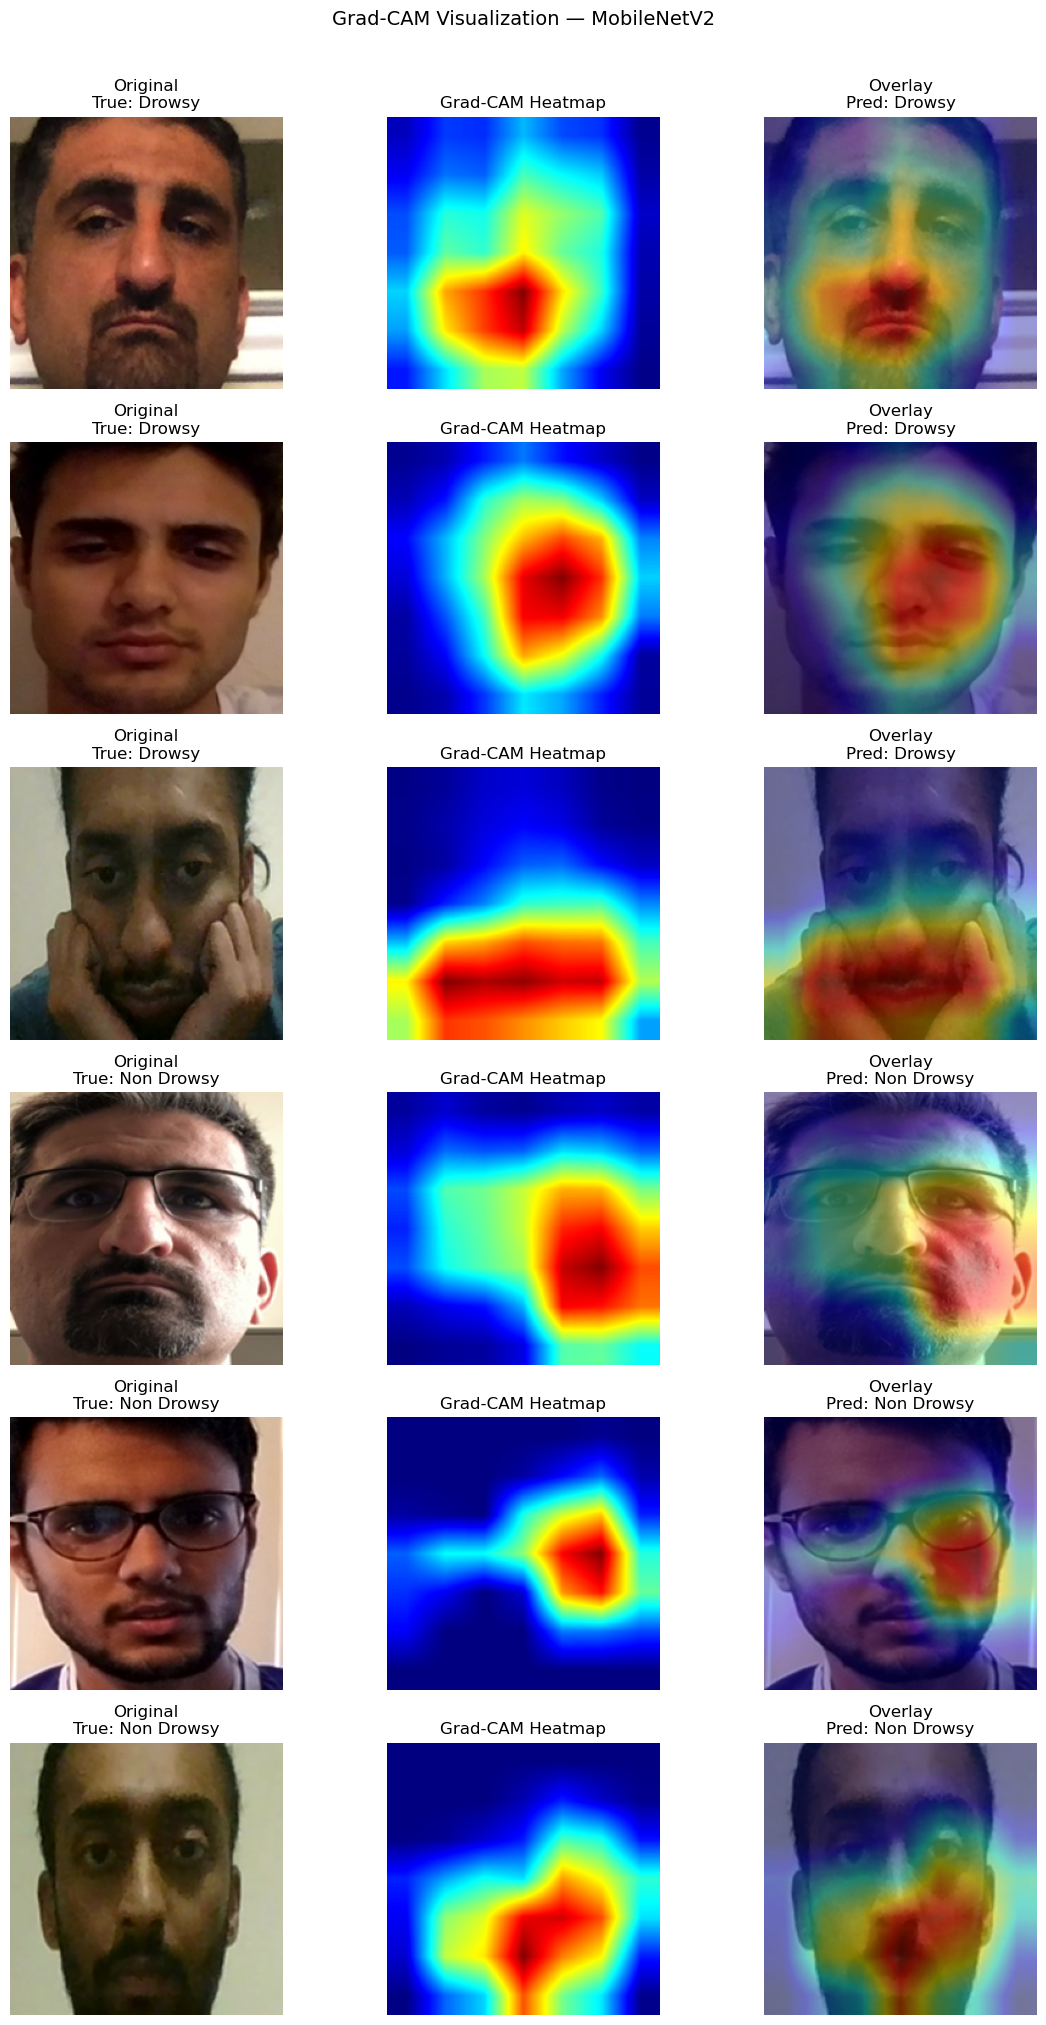

Grad-CAM visualization complete


In [36]:
# Target layer — last conv layer of MobileNetV2
target_layer = mobilenet_model.features[-1]
gradcam = GradCAM(mobilenet_model, target_layer)

# Transform for single image
single_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def apply_gradcam(img_path, label_name):
    # Load image
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((224, 224))
    
    # Prepare tensor
    input_tensor = single_transform(img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True
    
    # Generate heatmap
    heatmap, pred_class = gradcam.generate(input_tensor)
    
    # Resize heatmap to image size
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Overlay on original image
    img_array = np.array(img_resized)
    superimposed = cv2.addWeighted(img_array, 0.6, heatmap_colored, 0.4, 0)
    
    class_names = ['Drowsy', 'Non Drowsy']
    pred_name = class_names[pred_class]
    
    return img_resized, heatmap_colored, superimposed, pred_name, label_name

# Get sample images
drowsy_samples = [os.path.join(data_dir, 'Drowsy', f) 
                  for f in os.listdir(os.path.join(data_dir, 'Drowsy')) 
                  if f.endswith('.png')][:3]

non_drowsy_samples = [os.path.join(data_dir, 'Non Drowsy', f) 
                      for f in os.listdir(os.path.join(data_dir, 'Non Drowsy')) 
                      if f.endswith('.png')][:3]

# Plot
fig, axes = plt.subplots(6, 3, figsize=(12, 20))
samples = [(p, 'Drowsy') for p in drowsy_samples] + \
          [(p, 'Non Drowsy') for p in non_drowsy_samples]

for row, (img_path, label) in enumerate(samples):
    orig, heatmap, overlay, pred, true = apply_gradcam(img_path, label)
    
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'Original\nTrue: {true}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(heatmap)
    axes[row, 1].set_title('Grad-CAM Heatmap')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'Overlay\nPred: {pred}')
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM Visualization — MobileNetV2', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Grad-CAM visualization complete")